# Problem Statement: Simple Linear Regression Analysis

### Goal
The goal of this project is to analyze the relationship between **Temperature** and **Material Expansion** to create a predictive model.

### Dataset Description
The provided CSV file contains two numerical columns:
1. **Temperature_C**: The independent variable (Input).
2. **Expansion_mm**: The dependent variable (Output).

*Note: The dataset contains missing values that must be handled during the cleaning phase.*

### Tasks
* **Data Cleaning:** Identify rows with missing data and apply a simple imputation or removal strategy.
* **Visualization:** Create a scatter plot to confirm that the data follows a linear trend.
* **Modeling:** Use Linear Regression to find the line of best fit.
* **Prediction:** Use your model to estimate the expansion of the material at **35°C**.

# Solution

## Data Preprocessing

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('./data.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Temperature_C  151 non-null    float64
 1   Expansion_mm   151 non-null    float64
dtypes: float64(2)
memory usage: 2.5 KB


In [29]:
X = np.array(df.iloc[:, :-1])
y = np.array(df.iloc[:, -1])

In [30]:
from sklearn.impute import SimpleImputer

mean_strategy = SimpleImputer(missing_values=np.nan, strategy='mean')

X = np.array(mean_strategy.fit_transform(X.reshape(-1,1)))

y = np.array(mean_strategy.fit_transform(y.reshape(-1,1))).flatten()

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()
regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


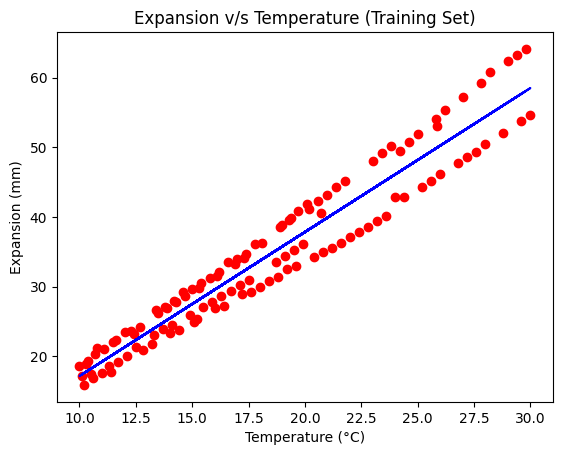

In [33]:
plt.scatter(X_train, y_train, color='red')
plt.plot(X_train, regressor.predict(X_train), color='blue')

plt.title("Expansion v/s Temperature (Training Set)")
plt.xlabel("Temperature (°C)")
plt.ylabel("Expansion (mm)")

plt.show()

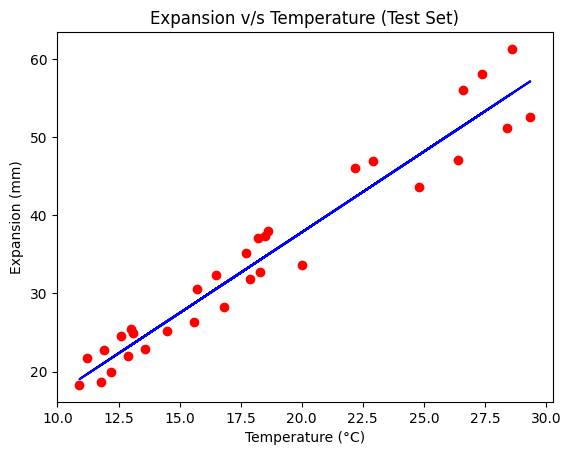

In [34]:
plt.scatter(X_test, y_test, color='red')
plt.plot(X_test, regressor.predict(X_test), color='blue')

plt.title("Expansion v/s Temperature (Test Set)")
plt.xlabel("Temperature (°C)")
plt.ylabel("Expansion (mm)")

plt.show()

In [35]:
slope = regressor.coef_[0]
intercept = regressor.intercept_

print(f"Slope = {regressor.coef_[0]}")
print(f"Intercept = {regressor.intercept_}")
print("\nThe regression equation is :-")

if(intercept < 0):
    print(f"y = {slope}x - {abs(intercept)}")
else:
    print(f"y = {slope}x + {intercept}")

Slope = 2.065409941247055
Intercept = -3.4764158842944326

The regression equation is :-
y = 2.065409941247055x - 3.4764158842944326


In [36]:
ans = regressor.predict([[35]])[0]
print(f"Expansion at temperature of 35°C = {ans} mm")

Expansion at temperature of 35°C = 68.81293205935248 mm
